In [1]:
import json

import polars as pl
import polars.selectors as cs

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import os

In [15]:
results_bka = pl.read_csv(
    "../../../Misc/LimeSurvey/results/results-bka.tsv", separator="\t"
)
results_ms = pl.read_csv(
    "../../../Misc/LimeSurvey/results/results-mschaaf.tsv",
    separator="\t",
    schema=results_bka.schema,
).slice(0, 1)
results_kb = pl.read_csv(
    "../../../Misc/LimeSurvey/results/results-kboenisch.csv",
).slice(0, 1)
results_kb = results_kb.rename(dict(zip(results_kb.columns, results_bka.columns))).cast(
    results_bka.schema
)

In [16]:
results = pl.concat([results_bka.filter(pl.col("id").ne(4)), results_ms, results_kb]).filter(
    pl.col("id").is_not_null()  # & pl.col("submitdate").ne("")
)
columns_not_ = (
    results.head(1).select(cs.matches(r"^text.*|^groupTime\d+|.*Time$")).columns
)
results = results.select(pl.col("*").exclude(columns_not_))
results

id,submitdate,lastpage,startlanguage,seed,startdate,datestamp,randomUserId,randomGroupId,displayVariables,LingErfahrungen[Beruf],LingErfahrungen[Berufcomment],LingErfahrungen[Ausbildung],LingErfahrungen[Ausbildungcomment],LingErfahrungen[privat],LingErfahrungen[privatcomment],LingErfahrungen[keine],LingErfahrungen[keinecomment],SelbstVOR,GenAIErfahrung[Beruf],GenAIErfahrung[Berufcomment],GenAIErfahrung[Ausbildung],GenAIErfahrung[Ausbildungcomment],GenAIErfahrung[privat],GenAIErfahrung[privatcomment],GenAIErfahrung[keine],GenAIErfahrung[keinecomment],selectcb525693,querycb525693,verdictcb525693,partialPctcb525693,partialTxtcb525693,certaincb525693,detailcb525693,detailcb525693[comment],select1193a26c,query1193a26c,…,certain46d7f400,detail46d7f400,detail46d7f400[comment],select6a4b2298,query6a4b2298,verdict6a4b2298,partialPct6a4b2298,partialTxt6a4b2298,certain6a4b2298,detail6a4b2298,detail6a4b2298[comment],select97778d88,query97778d88,verdict97778d88,partialPct97778d88,partialTxt97778d88,certain97778d88,detail97778d88,detail97778d88[comment],selectfbb0337c,queryfbb0337c,verdictfbb0337c,partialPctfbb0337c,partialTxtfbb0337c,certainfbb0337c,detailfbb0337c,detailfbb0337c[comment],select233bc21f,query233bc21f,verdict233bc21f,partialPct233bc21f,partialTxt233bc21f,certain233bc21f,detail233bc21f,detail233bc21f[comment],feedback,interviewtime
i64,str,i64,str,i64,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,f64
5,"""2026-03-10 17:39:41.000""",23,"""de-informal""",291014355,"""2026-03-10 16:59:19.000""","""2026-03-10 17:39:41.000""",929081,"""1""","""""","""Ja""","""Mitarbeiterin der Autorenerken…","""Ja""","""Promotion germanistische Sprac…","""Nein""","""""","""Nein""","""""","""4""","""Ja""","""berufliche Befassung mit Erken…","""Nein""","""""","""Ja""","""Spielereien mit Bild-/Video-/M…","""Nein""","""""","""cb525693-ec2a-4311-a9c3-b415b3…","""""","""KI-generiert""","""""","""""",5,"""einmal durchgelesen""","""""","""1193a26c-94f5-4229-99c6-4aae42…","""""",…,"""5""","""nur überflogen""","""""","""6a4b2298-0af2-4e42-ba67-c59596…","""""","""rein menschlich verfasst""","""""","""""","""2""","""mehrmals und/oder intensiver d…","""""","""97778d88-254a-4872-b7c7-6f5578…","""""","""teilweise KI-generiert""","""30""",""" Es ist an der Zeit, dass wir …","""2""","""mehrmals und/oder intensiver d…","""""","""fbb0337c-1775-4d8f-b08d-026dd1…","""""","""KI-generiert""","""""","""""","""1""","""mehrmals und/oder intensiver d…","""""","""233bc21f-42c2-478b-82b9-b7581b…","""""","""teilweise KI-generiert""","""25""","""Wir stehen an einem entscheide…","""2""","""mehrmals und/oder intensiver d…","""""","""""",2429.64
6,"""2026-03-11 13:38:44.000""",23,"""de-informal""",2054272226,"""2026-03-11 11:21:58.000""","""2026-03-11 13:38:43.000""",143310,"""0""","""""","""Ja""","""sachbearbeitend im Bereich Aut…","""Nein""","""""","""Nein""","""""","""Nein""","""""","""4""","""Nein""","""""","""Nein""","""""","""Ja""","""ab und an Verwendung von KI, a…","""Nein""","""""","""e11f8fd8-ebb3-446e-bee4-f9f2b5…","""""","""rein menschlich verfasst""","""""","""""",2,"""mehrmals und/oder intensiver d…","""ca. 3x (zügig) gelesen, grob a…","""5c5e9394-d2c4-4723-a305-7cde55…","""""",…,"""3""","""einmal durchgelesen""","""""","""b39e8a76-8b08-44e4-8ec8-bdcce8…","""""","""rein menschlich verfasst""","""""","""""","""3""","""einmal durchgelesen""","""""","""57f563b7-52ab-4257-9733-c33517…","""""","""rein menschlich verfasst""","""""","""""","""3""","""einmal durchgelesen""","""""","""b2ddf6eb-9ed6-4d46-80d1-7cdc95…","""""","""rein menschlich verfasst""","""""","""""","""4""","""einmal durchgelesen""","""""","""0becd46d-2d3e-4b58-b8f1-219c90…","""""","""teilweise KI-generiert""","""15""","""möglw. u. a. dieser Teil: Dies…","""3""","""einmal durchgelese

In [ ]:
results.select(pl.col("SelbstVOR").cast(int, strict=False)).describe()

statistic,SelbstVOR
str,f64
"""count""",8.0
"""null_count""",2.0
"""mean""",3.5
"""std""",0.755929
"""min""",2.0
"""25%""",3.0
"""50%""",4.0
"""75%""",4.0
"""max""",4.0


In [124]:
results.select(pl.col("SelbstVOR").cast(int, strict=False))["SelbstVOR"].value_counts()

SelbstVOR,count
i64,u32
3,2
4,5
2,1
null,2


In [ ]:
results["GenAIErfahrung[Beruf]"].value_counts()

GenAIErfahrung[Beruf],count
str,u32
"""N/A""",1
"""Ja""",6
"""Nein""",3


In [ ]:
results["GenAIErfahrung[Ausbildung]"].value_counts()

GenAIErfahrung[Ausbildung],count
str,u32
"""Nein""",7
"""Ja""",2
"""N/A""",1


In [117]:
results["GenAIErfahrung[privat]"].value_counts()

GenAIErfahrung[privat],count
str,u32
"""Ja""",7
"""Nein""",2
"""N/A""",1


In [125]:
results["LingErfahrungen[Beruf]"].value_counts()

LingErfahrungen[Beruf],count
str,u32
"""Ja""",7
"""Nein""",2
"""N/A""",1


In [126]:
results["LingErfahrungen[Ausbildung]"].value_counts()

LingErfahrungen[Ausbildung],count
str,u32
"""N/A""",1
"""Ja""",5
"""Nein""",4


In [128]:
results["LingErfahrungen[privat]"].value_counts()

LingErfahrungen[privat],count
str,u32
"""Nein""",8
"""Ja""",1
"""N/A""",1


In [17]:
results_both = (
    results.select(
        "randomUserId",
        *[
            pl.struct(
                pl.col(
                    f"select{key} verdict{key} partialPct{key} partialTxt{key} certain{key} detail{key} detail{key}[comment]".split()
                )
            ).alias(key)
            for key in (
                c.removeprefix("select")
                for c in results.head(1).select(cs.matches(r"select.+")).columns
            )
        ],
    )
    .with_columns(
        pl.col(pl.Struct).struct.rename_fields(
            [
                "id",
                "verdict",
                "partialPct",
                "partialTxt",
                "certain",
                "detail",
                "detail_comment",
            ]
        )
    )
    .unpivot(index="randomUserId")
    .select(
        randomUserId=pl.col("randomUserId"),
        group=pl.col("variable"),
        id=pl.col("value").struct.field("id"),
        verdict=pl.col("value").struct.field("verdict"),
        partialPct=pl.col("value")
        .struct.field("partialPct")
        .cast(pl.UInt16, strict=False),
        partialTxt=pl.col("value").struct.field("partialTxt"),
        certain=pl.col("value").struct.field("certain").cast(pl.UInt8, strict=False),
        detail=pl.col("value").struct.field("detail"),
        detail_comment=pl.col("value").struct.field("detail_comment"),
    )
)

In [18]:
group_a, group_b = results.partition_by("selectcb525693")

results_group_a = (
    group_a.select(
        "randomUserId",
        *[
            pl.struct(
                pl.col(
                    f"select{key} verdict{key} partialPct{key} partialTxt{key} certain{key} detail{key} detail{key}[comment]".split()
                )
            ).alias(key)
            for key in (
                c.removeprefix("select")
                for c in group_a.head(1).select(cs.matches(r"select.+")).columns
            )
        ],
    )
    .with_columns(
        pl.col(pl.Struct).struct.rename_fields(
            [
                "id",
                "verdict",
                "partialPct",
                "partialTxt",
                "certain",
                "detail",
                "detail_comment",
            ]
        )
    )
    .unpivot(index="randomUserId")
    .select(
        randomUserId=pl.col("randomUserId"),
        group=pl.col("variable"),
        id=pl.col("value").struct.field("id"),
        verdict=pl.col("value").struct.field("verdict"),
        partialPct=pl.col("value")
        .struct.field("partialPct")
        .cast(pl.UInt16, strict=False),
        partialTxt=pl.col("value").struct.field("partialTxt"),
        certain=pl.col("value").struct.field("certain").cast(pl.UInt8, strict=False),
        detail=pl.col("value").struct.field("detail"),
        detail_comment=pl.col("value").struct.field("detail_comment"),
    )
)

In [19]:
def clean_suffix(text: str) -> str:
    return (
        text.removesuffix(" Vielen Dank.")
        .removesuffix(" Ich bitte Sie um Zustimmung.")
        .removesuffix(" Aber manche.")
    )

In [31]:
selection = json.load(
    open("../../../Misc/LimeSurvey/selection.json", "r", encoding="utf-8")
)

samples = []
for key, ids in selection.items():
    random_samples = json.load(
        open(
            key.replace(
                "H:/Projekte/GhostWriter/data/ghostwriter",
                "../data/ghostwriter",
            ),
            "r",
            encoding="utf-8",
        )
    )
    random_samples.pop("dataset")
    random_samples.pop("max_length")
    random_samples.pop("seed")
    data_ = {s["id"]: s for s in random_samples.pop("data")}
    for id_ in ids:
        human = {
            "id": data_[id_]["source"],
            "source": data_[id_]["source"],
            "label": "human",
            "label_survey": "rein menschlich verfasst",
            "text": data_[id_]["text_source"],
        } | random_samples
        human["words"] = len(
            human["text"].replace("-", "- ").replace(" - ", " ").split()
        )
        samples.append(human)

        agent = {
            "id": data_[id_]["id"],
            "source": data_[id_]["source"],
            "label": "agent" if random_samples["type"] == "fulltext" else "agent_chunk",
            "label_survey": "KI-generiert"
            if random_samples["type"] == "fulltext"
            else "teilweise KI-generiert",
            "text": data_[id_]["text"],
        } | random_samples
        agent["words"] = len(
            agent["text"].replace("-", "- ").replace(" - ", " ").split()
        )
        if random_samples["type"] == "chunk":
            common_prefix = " ".join(
                os.path.commonprefix(
                    [human["text"].split(" "), agent["text"].split(" ")]
                )
            )
            common_suffix = " ".join(
                os.path.commonprefix(
                    [
                        clean_suffix(human["text"]).split(" ")[::-1],
                        agent["text"].split(" ")[::-1],
                    ]
                )[::-1]
            )
            ai_chunk = (
                agent["text"]
                .removeprefix(common_prefix)
                .removesuffix(common_suffix)
                .strip()
            )
            agent["ai_chunk"] = ai_chunk
            agent["ai_chunk_length"] = len(ai_chunk)
            agent["ai_chunk_start"] = len(common_prefix)
            agent["ai_chunk_end"] = len(agent["text"]) - len(common_suffix)
            agent["ai_chunk_ratio"] = len(ai_chunk) / len(agent["text"])
            agent["ai_chunk_words"] = len(
                agent["ai_chunk"].replace("-", "- ").replace(" - ", " ").split()
            )
        samples.append(agent)

# print(json.dumps(samples, indent=4, ensure_ascii=False))

In [21]:
samples_df = pl.DataFrame(samples)
samples_df.sort("source")

id,source,label,label_survey,text,agent,domain,type,words,ai_chunk,ai_chunk_length,ai_chunk_start,ai_chunk_end,ai_chunk_ratio,ai_chunk_words
str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,i64
"""1193a26c-94f5-4229-99c6-4aae42…","""1193a26c-94f5-4229-99c6-4aae42…","""human""","""rein menschlich verfasst""","""Herr Präsident! Werte Kollegin…","""gpt-4o-mini""","""bundestag""","""chunk""",425,null,null,null,null,null,null
"""5c5e9394-d2c4-4723-a305-7cde55…","""1193a26c-94f5-4229-99c6-4aae42…","""agent_chunk""","""teilweise KI-generiert""","""Herr Präsident! Werte Kollegin…","""gpt-4o-mini""","""bundestag""","""chunk""",432,"""Wir müssen uns auch vor Augen …",549,2367,2917,0.188207,85
"""119e7730-4860-45ca-9f7e-82917f…","""119e7730-4860-45ca-9f7e-82917f…","""human""","""rein menschlich verfasst""","""Indem wir ganz eng mit der Reg…","""gpt-4o-mini""","""bundestag""","""chunk""",212,null,null,null,null,null,null
"""8e285d3f-77a0-4aa1-9f2d-38a405…","""119e7730-4860-45ca-9f7e-82917f…","""agent_chunk""","""teilweise KI-generiert""","""Indem wir ganz eng mit der Reg…","""gpt-4o-mini""","""bundestag""","""chunk""",196,"""Wir müssen uns auch der Tatsac…",831,536,1368,0.607456,115
"""180dd5f7-3df0-44df-b2d2-757cbd…","""180dd5f7-3df0-44df-b2d2-757cbd…","""human""","""rein menschlich verfasst""","""Herr Präsident! Liebe Kollegin…","""gemma2:9b""","""bundestag""","""fulltext""",439,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""d71f7dd2-746e-4b07-b56c-8f8372…","""e27fee7c-482b-478e-aaab-cfb182…","""agent""","""KI-generiert""","""Im Jahr 2019 konnte Deutschlan…","""gpt-4o-mini""","""bundestag""","""fulltext""",100,null,null,null,null,null,null
"""e66e9bff-481d-4432-bf37-d25b2c…","""e66e9bff-481d-4432-bf37-d25b2c…","""human""","""rein menschlich verfasst""","""Frau Präsidentin! Meine sehr v…","""gpt-4o-mini""","""bundestag""","""fulltext""",479,null,null,null,null,null,null
"""fd745c0c-244f-4cf9-8bc0-1098dc…","""e66e9bff-481d-4432-bf37-d25b2c…","""agent""","""KI-generiert""","""Sehr geehrte Damen und Herren,…","""gpt-4o-mini""","""bundestag""","""fulltext""",446,null,null,null,null,null,null


In [112]:
samples_df.select("words").describe()

statistic,words
str,f64
"""count""",40.0
"""null_count""",0.0
"""mean""",342.35
"""std""",144.239038
"""min""",66.0
"""25%""",253.0
"""50%""",375.0
"""75%""",439.0
"""max""",628.0


In [22]:
eval_group_a = results_group_a.join(
    samples_df.select(
        "id", "label_survey", "type", "label", "agent", "ai_chunk", "ai_chunk_ratio"
    ),
    on="id",
).with_columns(
    verdict_given=pl.col("verdict").ne(""),
    correct=pl.col("verdict").eq(pl.col("label_survey")).cast(int),
)
score_group_a = eval_group_a.with_columns(
    certain=pl.col("certain").fill_null(1)
).with_columns(weighted=pl.col("correct").mul(pl.col("certain")))

In [ ]:
acc_by_label_user = (
    score_group_a.filter(pl.col("verdict_given"))
    .group_by("randomUserId", "label", "agent")
    .agg(
        pl.sum("correct").alias("correct"),
        pl.mean("correct").alias("accuracy"),
        pl.mean("weighted").truediv(5).alias("accuracy_weighted"),
        pl.count("correct").alias("total"),
    )
    .sort("randomUserId", "label", "agent")
)
acc_by_type_user = (
    score_group_a.filter(pl.col("verdict_given"))
    .group_by("randomUserId", "type", "agent")
    .agg(
        pl.sum("correct").alias("correct"),
        pl.mean("correct").alias("accuracy"),
        pl.mean("weighted").truediv(5).alias("accuracy_weighted"),
        pl.count("correct").alias("total"),
    )
    .sort("randomUserId", "type", "agent")
)

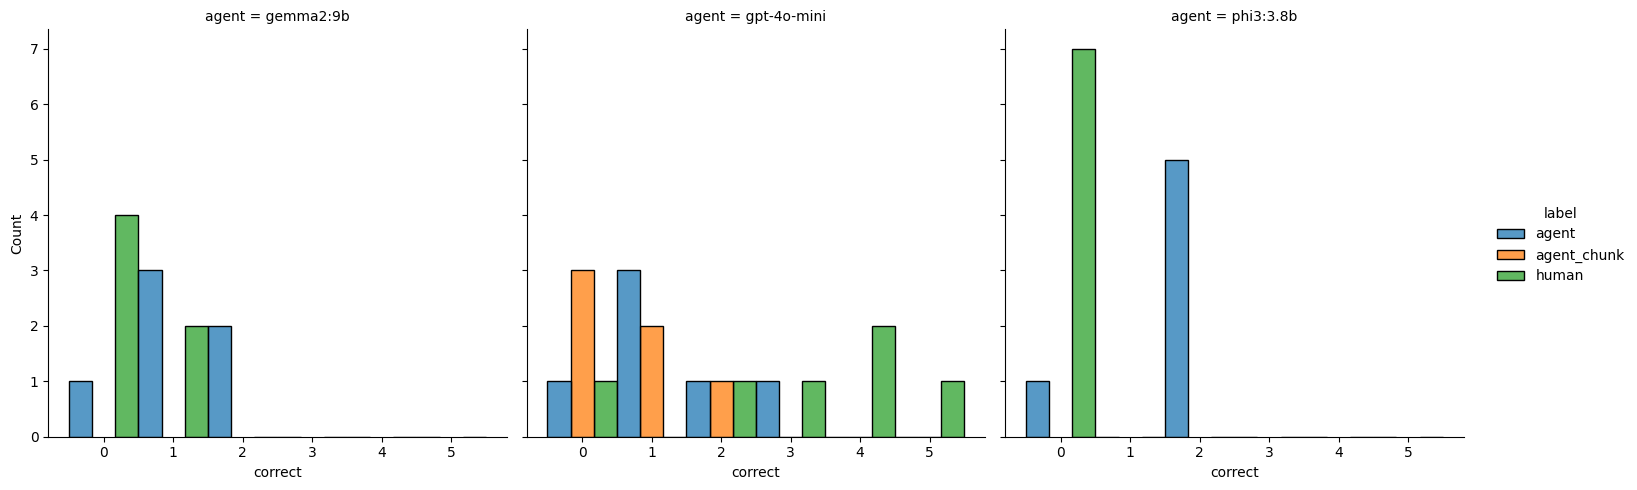

In [33]:
sns.displot(
    acc_by_label_user.with_columns(count=pl.col("correct")).to_pandas(),
    x="correct",
    hue="label",
    col="agent",
    discrete=True,
    multiple="dodge",
)

## Majority Vote
### Three Class

In [173]:
majority_vote_data = score_group_a.filter(pl.col("verdict_given")).group_by("id").agg(
    type=pl.col("type").first(),
    agent=pl.col("agent").first(),
    label=(
        pl.col("label_survey")
        .first()
        .replace("rein menschlich verfasst", 0)
        .replace("KI-generiert", 1)
        .replace("teilweise KI-generiert", 2)
        .cast(int)
    ),
    label_str=pl.col("label").first(),
    HW=pl.col("verdict").eq("rein menschlich verfasst").cast(int).sum(),
    AIg=pl.col("verdict").eq("KI-generiert").cast(int).sum(),
    AIf=pl.col("verdict").eq("teilweise KI-generiert").cast(int).sum(),
)

majority_vote_3c = majority_vote_data.with_columns(
    majority_verdict=(
        pl.when(pl.col("HW").gt(pl.col("AIg")))
        .then(pl.lit(0))
        .when(pl.col("AIg").gt(pl.col("AIf")))
        .then(pl.lit(1))
        .otherwise(pl.lit(2))
    ),
    majority_weight=(
        pl.when(pl.col("HW").gt(pl.col("AIg")))
        .then(pl.col("HW"))
        .when(pl.col("AIg").gt(pl.col("AIf")))
        .then(pl.col("AIg"))
        .otherwise(pl.col("AIf"))
    ),
    majority_total=pl.col("HW") + pl.col("AIg") + pl.col("AIf"),
).with_columns(
    correct=pl.col("majority_verdict").eq(pl.col("label")).cast(int)
)
majority_vote_3c

id,type,agent,label,label_str,HW,AIg,AIf,majority_verdict,majority_weight,majority_total,correct
str,str,str,i64,str,i64,i64,i64,i32,i64,i64,i64
"""cb525693-ec2a-4311-a9c3-b415b3…","""fulltext""","""phi3:3.8b""",0,"""human""",0,5,1,1,5,6,0
"""a002afbf-b670-48f0-8b5c-d32a4f…","""fulltext""","""phi3:3.8b""",0,"""human""",0,5,1,1,5,6,0
"""d71f7dd2-746e-4b07-b56c-8f8372…","""fulltext""","""gpt-4o-mini""",1,"""agent""",3,3,0,1,3,6,1
"""8fbabbf1-ab65-47f6-935c-4fed17…","""fulltext""","""gemma2:9b""",0,"""human""",2,2,2,2,2,6,0
"""967a3ec6-3e19-4efc-a858-08c938…","""fulltext""","""phi3:3.8b""",1,"""agent""",1,5,0,1,5,6,1
…,…,…,…,…,…,…,…,…,…,…,…
"""29a61e5c-fca1-444d-a47d-692945…","""fulltext""","""gemma2:9b""",1,"""agent""",1,2,3,2,3,6,0
"""1193a26c-94f5-4229-99c6-4aae42…","""chunk""","""gpt-4o-mini""",0,"""human""",3,1,2,0,3,6,1
"""fbb0337c-1775-4d8f-b08d-026dd1…","""chunk""","""gpt-4o-mini""",0,"""human""",2,3,1,1,3,6,0


In [174]:
majority_vote_3c.group_by("agent", "label_str").agg(
    accuracy=pl.col("correct").mean(),
).sort("agent", "label_str")

agent,label_str,accuracy
str,str,f64
"""gemma2:9b""","""agent""",0.5
"""gemma2:9b""","""human""",0.0
"""gpt-4o-mini""","""agent""",0.666667
"""gpt-4o-mini""","""agent_chunk""",0.0
"""gpt-4o-mini""","""human""",0.833333
"""phi3:3.8b""","""agent""",1.0
"""phi3:3.8b""","""human""",0.0


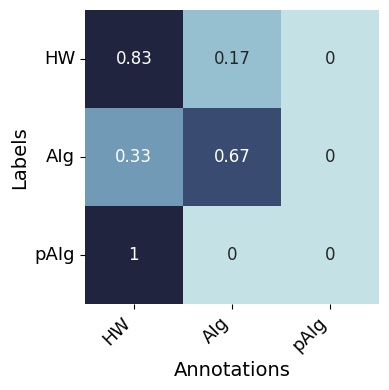

In [198]:
df_pd = (
    majority_vote_3c.filter(pl.col("agent").eq("gpt-4o-mini"))
    .select("label", "majority_verdict")
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(4, 4), )
sns.heatmap(
    confusion_matrix(*df_pd.T.values, normalize="true"),
    annot=True,
    xticklabels=["HW", "AIg", "pAIg"],
    yticklabels=["HW", "AIg", "pAIg"],
    cmap=sns.cubehelix_palette(rot=-0.2),
    cbar=False,
    square=True,
    ax=ax,
    annot_kws={"size": 12},
)
ax.set_xlabel("Annotations", size=14)
ax.set_ylabel("Labels", size=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", va="top", size=13)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right", size=13)

plt.tight_layout()
plt.savefig("../figures/evaluation/heatmap-majority_vote-p=10-c=3.pgf")
plt.savefig("../figures/evaluation/heatmap-majority_vote-p=10-c=3.png", dpi=300)
plt.show()

### Two Class - Merging both AI-Categories



In [108]:
majority_vote_2c = (
    majority_vote_data.with_columns(
        AIm=pl.col("AIg") + pl.col("AIf"),
    )
    .with_columns(
        label=pl.col("label").clip(0, 1),
        label_str=pl.col("label_str").replace("agent_chunk", "agent"),
        majority_verdict=(
            pl.when(pl.col("HW").gt(pl.col("AIm"))).then(pl.lit(0)).otherwise(pl.lit(1))
        ),
        majority_weight=(
            pl.when(pl.col("HW").gt(pl.col("AIm")))
            .then(pl.col("HW"))
            .otherwise(pl.col("AIm"))
        ),
        majority_total=pl.col("HW") + pl.col("AIm"),
    )
    .with_columns(correct=pl.col("majority_verdict").eq(pl.col("label")).cast(int))
)
majority_vote_2c

id,type,agent,label,label_str,HW,AIg,AIf,AIm,majority_verdict,majority_weight,majority_total,correct
str,str,str,i64,str,i64,i64,i64,i64,i32,i64,i64,i64
"""97778d88-254a-4872-b7c7-6f5578…","""fulltext""","""gpt-4o-mini""",0,"""human""",3,1,2,3,1,3,6,0
"""fd745c0c-244f-4cf9-8bc0-1098dc…","""fulltext""","""gpt-4o-mini""",1,"""agent""",2,1,3,4,1,4,6,1
"""8fbabbf1-ab65-47f6-935c-4fed17…","""fulltext""","""gemma2:9b""",0,"""human""",2,2,2,4,1,4,6,0
"""4172f2f7-8709-4446-8ca6-5007a6…","""fulltext""","""gemma2:9b""",0,"""human""",0,5,1,6,1,6,6,0
"""967a3ec6-3e19-4efc-a858-08c938…","""fulltext""","""phi3:3.8b""",1,"""agent""",1,5,0,5,1,5,6,1
…,…,…,…,…,…,…,…,…,…,…,…,…
"""d71f7dd2-746e-4b07-b56c-8f8372…","""fulltext""","""gpt-4o-mini""",1,"""agent""",3,3,0,3,1,3,6,1
"""cb525693-ec2a-4311-a9c3-b415b3…","""fulltext""","""phi3:3.8b""",0,"""human""",0,5,1,6,1,6,6,0
"""1193a26c-94f5-4229-99c6-4aae42…","""chunk""","""gpt-4o-mini""",0,"""human""",3,1,2,3,1,3,6,0


In [110]:
majority_vote_2c.group_by("agent", "label_str").agg(
    accuracy=pl.col("correct").mean(),
).sort("agent", "label_str")

agent,label_str,accuracy
str,str,f64
"""gemma2:9b""","""agent""",1.0
"""gemma2:9b""","""human""",0.0
"""gpt-4o-mini""","""agent""",0.5
"""gpt-4o-mini""","""human""",0.166667
"""phi3:3.8b""","""agent""",1.0
"""phi3:3.8b""","""human""",0.0


In [37]:
acc_by_id_label_agent = (
    score_group_a.filter(pl.col("verdict_given"))
    .group_by("id", "label", "agent")
    .agg(
        pl.sum("correct").alias("correct"),
        pl.mean("correct").alias("accuracy"),
        pl.mean("weighted").truediv(5).alias("accuracy_weighted"),
        pl.count("correct").alias("total"),
    )
    .sort("id", "label", "agent")
)

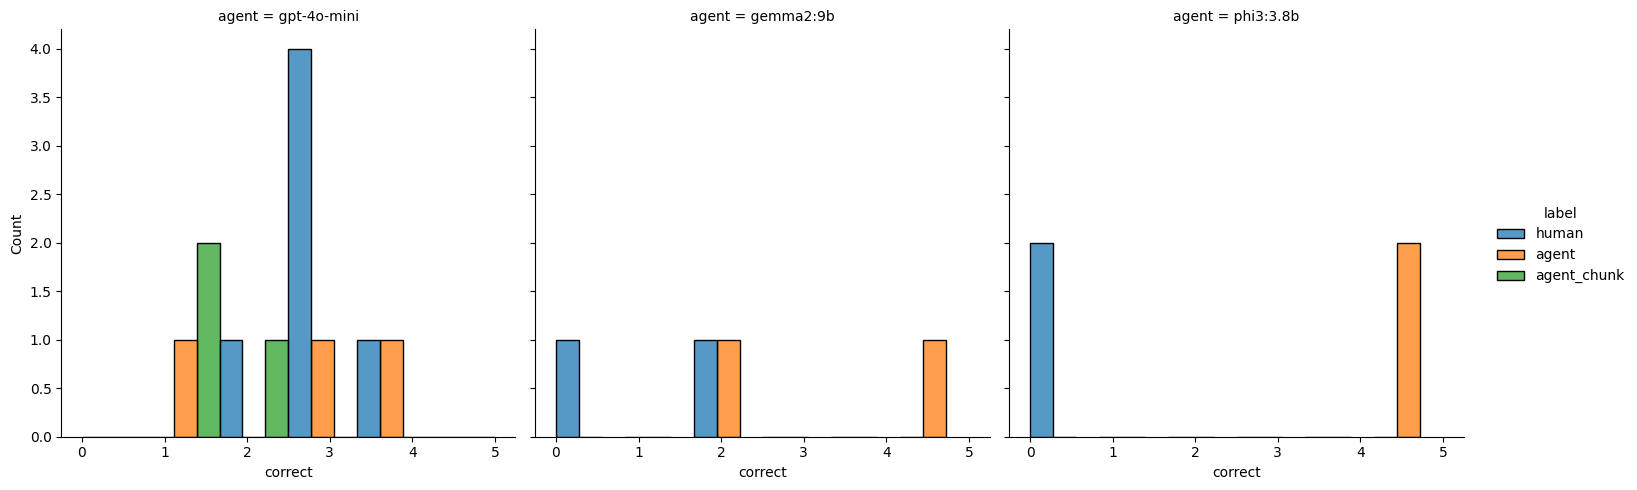

In [52]:
sns.displot(
    acc_by_id_label_agent.to_pandas(),
    x="correct",
    hue="label",
    col="agent",
    kind="hist",
    multiple="dodge",
)#.axes[0][0].set_xlim(0, 1)

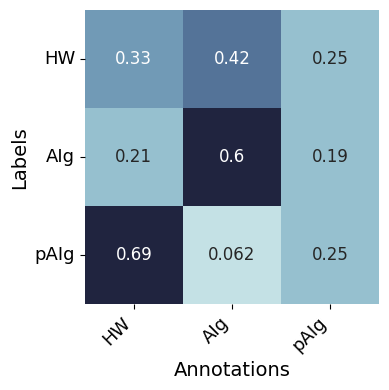

In [197]:
df_pd = (
    score_group_a.filter(
        pl.col("verdict_given")
    )
    .select("label_survey", "verdict")
    .with_columns(
        pl.col("*")
        .replace("rein menschlich verfasst", 0)
        .replace("KI-generiert", 1)
        .replace("teilweise KI-generiert", 2)
    )
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(
    confusion_matrix(*df_pd.T.values, normalize="true"),
    annot=True,
    xticklabels=["HW", "AIg", "pAIg"],
    yticklabels=["HW", "AIg", "pAIg"],
    cmap=sns.cubehelix_palette(rot=-0.2),
    cbar=False,
    square=True,
    ax=ax,
    annot_kws={"size": 12},
)
ax.set_xlabel("Annotations", size=14)
ax.set_ylabel("Labels", size=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", va="top", size=13)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right", size=13)

plt.tight_layout()
plt.savefig("../figures/evaluation/heatmap-individual-p=10-c=3.pgf")
plt.savefig("../figures/evaluation/heatmap-individual-p=10-c=3.png", dpi=300)
plt.show()

In [199]:
df_pd.T

,0,1,2,3,4,5,6,7,8,9,10,11
label,1,2,0,0,0,1,2,0,0,0,1,2
majority_verdict,1,0,0,0,0,1,0,0,0,1,0,0


<Axes: >

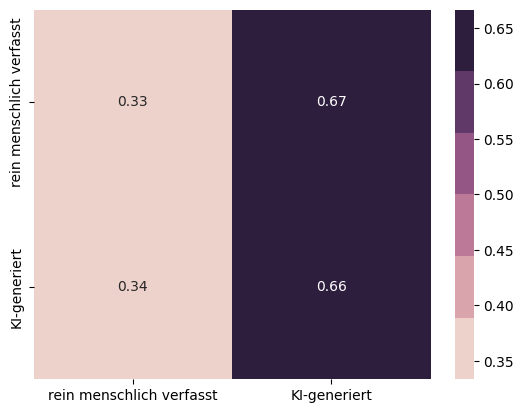

In [181]:
df_pd = (
    score_group_a.filter(
        pl.col("verdict_given")
    )
    .select("label_survey", "verdict")
    .with_columns(
        pl.col("*")
        .replace("rein menschlich verfasst", 0)
        .replace("KI-generiert", 1)
        .replace("teilweise KI-generiert", 1)
    )
    .to_pandas()
)

sns.heatmap(
    confusion_matrix(*df_pd.T.values, normalize="true"),
    annot=True,
    xticklabels=["rein menschlich verfasst", "KI-generiert"],
    yticklabels=["rein menschlich verfasst", "KI-generiert"],
    cmap=sns.cubehelix_palette(),
)

<Axes: >

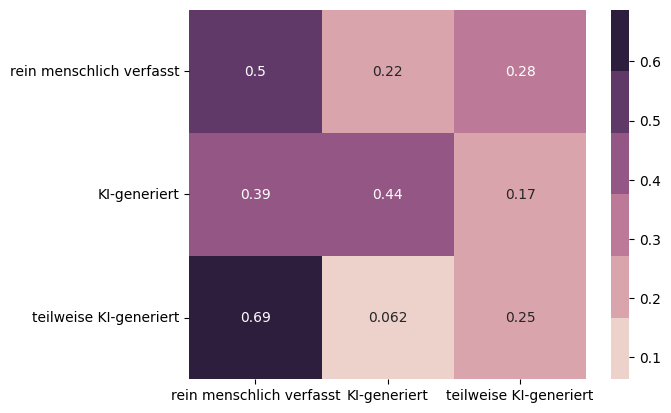

In [182]:
model = "gpt-4o-mini"
# model = "gemma2:9b"
# model = "phi3:3.8b"
df_pd = (
    score_group_a.filter(
        pl.col("verdict_given") & pl.col("agent").eq(model),
    )
    .select("label_survey", "verdict")
    .with_columns(
        pl.col("*")
        .replace("rein menschlich verfasst", 0)
        .replace("KI-generiert", 1)
        .replace("teilweise KI-generiert", 2)
    )
    .to_pandas()
)

sns.heatmap(
    confusion_matrix(*df_pd.T.values, normalize="true"),
    annot=True,
    xticklabels=["rein menschlich verfasst", "KI-generiert", "teilweise KI-generiert"],
    yticklabels=["rein menschlich verfasst", "KI-generiert", "teilweise KI-generiert"],
    cmap=sns.cubehelix_palette(),
)

In [26]:
eval_both = results_both.join(
    samples_df.select(
        "id", "label_survey", "type", "label", "agent", "ai_chunk", "ai_chunk_ratio"
    ),
    on="id",
).with_columns(
    verdict_given=pl.col("verdict").ne(""),
    correct=pl.col("verdict").eq(pl.col("label_survey")).cast(int),
)
score_both = eval_both.with_columns(
    certain=pl.col("certain").fill_null(1)
).with_columns(weighted=pl.col("correct").mul(pl.col("certain")))

<Axes: >

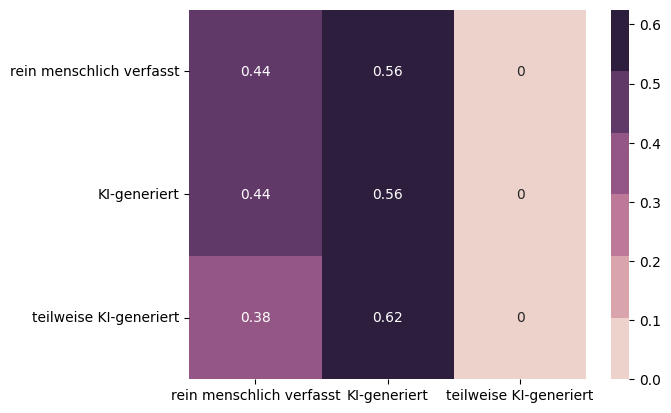

In [27]:
# model = "gpt-4o-mini"
model = "gemma2:9b"
# model = "phi3:3.8b"
df_pd = (
    score_both.filter(
        pl.col("verdict_given") & pl.col("agent").eq(model),
    )
    .select("verdict", "label_survey")
    .with_columns(
        pl.col("*")
        .replace("rein menschlich verfasst", 0)
        .replace("KI-generiert", 1)
        .replace("teilweise KI-generiert", 2)
    )
    .to_pandas()
)

sns.heatmap(
    confusion_matrix(*df_pd.T.values, normalize="true"),
    annot=True,
    xticklabels=["rein menschlich verfasst", "KI-generiert", "teilweise KI-generiert"],
    yticklabels=["rein menschlich verfasst", "KI-generiert", "teilweise KI-generiert"],
    cmap=sns.cubehelix_palette(),
)

<Axes: >

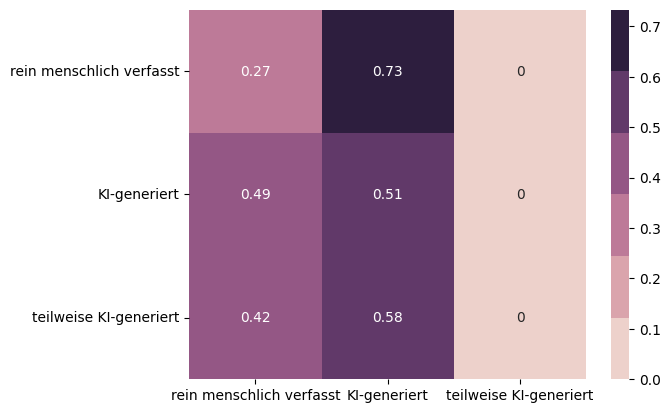

In [28]:
model = "gpt-4o-mini"
df_pd = (
    score_both.filter(
        pl.col("verdict_given") & pl.col("agent").ne(model),
    )
    .select("verdict", "label_survey")
    .with_columns(
        pl.col("*")
        .replace("rein menschlich verfasst", 0)
        .replace("KI-generiert", 1)
        .replace("teilweise KI-generiert", 2)
    )
    .to_pandas()
)

sns.heatmap(
    confusion_matrix(*df_pd.T.values, normalize="true"),
    annot=True,
    xticklabels=["rein menschlich verfasst", "KI-generiert", "teilweise KI-generiert"],
    yticklabels=["rein menschlich verfasst", "KI-generiert", "teilweise KI-generiert"],
    cmap=sns.cubehelix_palette(),
)

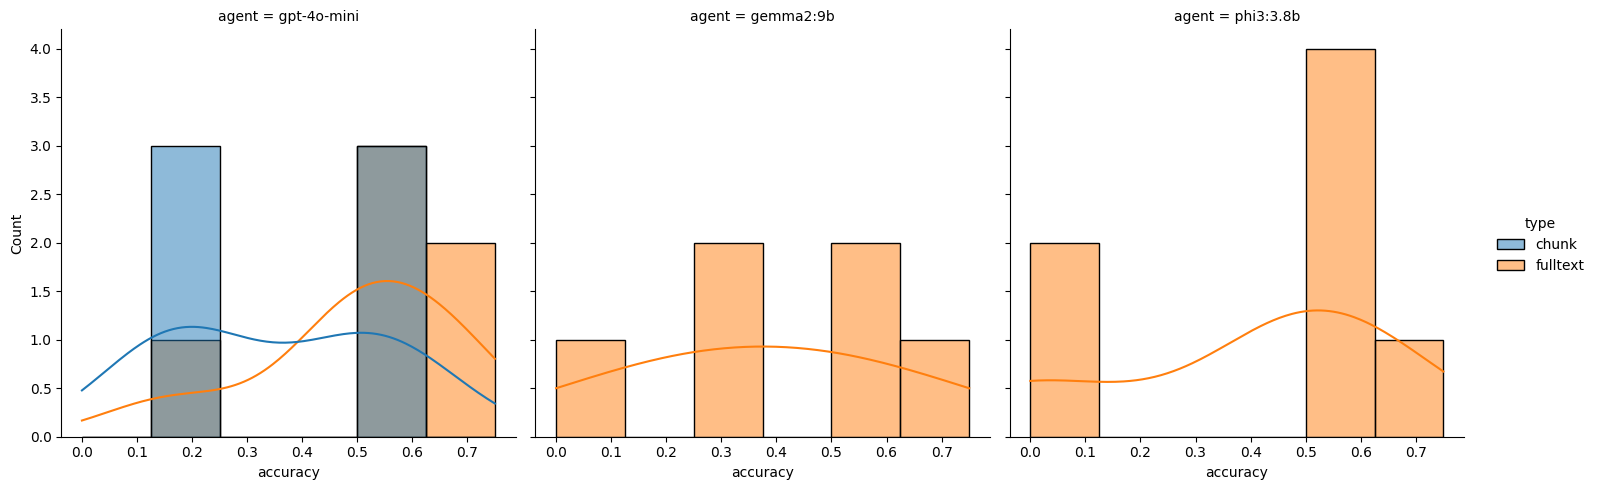

In [29]:
sns.displot(
    acc_by_type_user.with_columns(count=pl.col("correct")).to_pandas(),
    x="accuracy",
    hue="type",
    col="agent",
    kde=True,
)

In [30]:
for row in samples_df.filter(pl.col("label").eq("agent_chunk")).iter_rows(named=True):
    print(
        "<p>" +row["text"].replace(
            row["ai_chunk"],
            "<span style='background-color: #ff0000'>" + row["ai_chunk"] + "</span>",
        ) + "</p>"
    )

<p>Ich vermute, dass sich das Berliner Finanzamt diese Dinge überlegt hat. Das bedeutet in keiner Weise, dass wir die Tätigkeit gegen rechtsextreme Gedankengänge und Taten mit aller Macht bekämpfen. Ich würde sagen: Das Berliner Finanzamt ist näher am Berliner Senat als an der Bundesregierung, und Die Linke ist auch dort vertreten. Vielleicht kann man das auf Berliner Ebene noch einmal vertieft diskutieren. Herr Cezanne, möchten Sie es noch einmal versuchen? <span style='background-color: #ff0000'>Ich möchte an dieser Stelle betonen, dass der Kampf gegen Rechtsextremismus nicht nur eine Aufgabe der Behörden ist, sondern auch eine gesamtgesellschaftliche Verantwortung. Es ist entscheidend, dass wir alle gemeinsam aufstehen und uns gegen die Verbreitung von Hass und Intoleranz einsetzen. Die Zivilgesellschaft spielt hierbei eine zentrale Rolle.</span> Den Traum hat nicht jeder Finanzminister gehabt.</p>
<p>Moin, Herr Präsident! Meine Damen und Herren! Liebe Landsleute! Die Lockdown-Krise